<a href="https://colab.research.google.com/github/shantiidp/HITL_Memory_Spine_A/blob/dev/HITL_Memory_Spine_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human-in-the-Loop + Memory — ShopSmart Support System 🦴 Spine A Grows

## Why We Need Human-in-the-Loop

Consider these real scenarios at ShopSmart:

1. **Platinum Customer Complaint (High Stakes)**: Mrs. Mehra, a platinum-tier customer who has spent ₹8,50,000 on the platform over 3 years, writes: "I received a damaged laptop worth ₹1,20,000 and I want a full refund AND compensation for the inconvenience. If this isn't resolved today, I'm switching to Amazon." — This is NOT a routine returns query. A wrong response risks losing a high-value customer. An AI-generated response isn't sufficient; a human manager should review and approve the response before it's sent.

2. **High-Value Order Dispute (Financial Risk)**: A customer disputes a ₹75,000 order claiming they never received it, but tracking shows "delivered." — Approving a refund of this size without human verification creates financial risk. The AI should draft a response, but a human should approve the refund decision.

3. **Escalation Request (Emotional Customer)**: A customer writes: "I've contacted support 4 times about the same issue and nobody is helping. I want to speak to a manager." — The system should detect this escalation pattern and route to a human, not generate another automated response.

## What We're Building

1. **Human-in-the-Loop (HITL)**: The graph PAUSES at critical decision points and sends a rich payload to a human reviewer. The human reviews the AI's recommendation and provides their decision. The graph then RESUMES with the human's input.

2. **Memory**:
   - **Thread Memory (MemorySaver)**: The agent remembers the conversation within a session — if a customer asks a follow-up question, the agent has full context.
   - **Cross-Session Memory (InMemoryStore)**: The agent remembers customer history across different conversations — past tickets, purchase history, complaint patterns.

## How HITL Works in LangGraph

```
Query → [classify_query] → [handler] → [hitl_gate] → PAUSES...
                                              ↓ (human reviews)
                                        Command(resume=decision) → [send_response] → END
```

Two key LangGraph APIs:
- **`interrupt(payload)`**: Pauses the graph and sends all relevant info to the human
- **`Command(resume=decision)`**: Human provides their decision, graph resumes

In [1]:
%%capture
!pip install langchain langchain-openai langgraph pydantic

In [2]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import interrupt, Command
from IPython.display import Image, display, Markdown
import json

## Extend the Lab 5 AgentState

In Lab 5, our AgentState had 4 fields: `customer_query`, `category`, `priority`, `response`.
Now we add fields for HITL and memory.

In [3]:
class AgentState(TypedDict):
    # --- From Lab 5 (unchanged) ---
    customer_query: str
    category: str          # order_status, returns, billing, product_info, escalation
    priority: str          # low, medium, high
    response: str          # AI-generated response

    # --- NEW: HITL fields ---
    customer_id: str       # To look up customer tier and history
    customer_tier: str     # bronze, silver, platinum
    order_value: float     # For high-value threshold checks
    needs_human_review: bool   # Flag set by hitl_gate
    human_decision: dict   # Filled after human reviews (approve/modify/reject + notes)

    # --- NEW: Memory fields ---
    conversation_history: str   # Summary of past interactions (from InMemoryStore)

print("AgentState defined with", len(AgentState.__annotations__), "fields")

AgentState defined with 10 fields


## RouteDecision Model + LLM

Same Pydantic model from Lab 5 for structured classification. We add `escalation` as a new category.

In [4]:
class RouteDecision(BaseModel):
    """Classification of a customer support query."""
    category: Literal["order_status", "returns", "billing", "product_info", "escalation"] = Field(
        description="The category of the customer query"
    )
    priority: Literal["low", "medium", "high"] = Field(
        description="The priority level of the query"
    )

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
print("RouteDecision model and LLM initialized")

RouteDecision model and LLM initialized


## Synthetic Data

Same `ORDERS_DB` and `PRODUCTS_DB` from Lab 5, plus a new `CUSTOMERS_DB` for tier and history lookups.

In [5]:
# --- From Lab 5 (unchanged) ---
ORDERS_DB = {
    "ORD-1001": {"status": "shipped", "item": "Laptop", "eta": "2 days", "value": 75000},
    "ORD-1002": {"status": "delivered", "item": "Headphones", "eta": "Delivered", "value": 3500},
    "ORD-1003": {"status": "processing", "item": "Smartphone", "eta": "5 days", "value": 45000},
    "ORD-1004": {"status": "shipped", "item": "Washing Machine", "eta": "3 days", "value": 32000},
    "ORD-1005": {"status": "delivered", "item": "Gaming Laptop", "eta": "Delivered", "value": 120000},
}

PRODUCTS_DB = {
    "Laptop": {"warranty": "1 year", "return_window": "7 days", "category": "Electronics"},
    "Headphones": {"warranty": "6 months", "return_window": "15 days", "category": "Audio"},
    "Smartphone": {"warranty": "1 year", "return_window": "7 days", "category": "Electronics"},
    "Washing Machine": {"warranty": "2 years", "return_window": "10 days", "category": "Appliances"},
    "Gaming Laptop": {"warranty": "1 year", "return_window": "7 days", "category": "Electronics"},
}

# --- NEW for Lab 8 ---
CUSTOMERS_DB = {
    "CUST-001": {"name": "Ananya Sharma", "tier": "bronze", "total_spend": 15000, "past_tickets": 2},
    "CUST-002": {"name": "Rajesh Mehta", "tier": "platinum", "total_spend": 850000, "past_tickets": 8},
    "CUST-003": {"name": "Priya Verma", "tier": "silver", "total_spend": 45000, "past_tickets": 5},
    "CUST-004": {"name": "Vikram Singh", "tier": "bronze", "total_spend": 8000, "past_tickets": 1},
    "CUST-005": {"name": "Sunita Reddy", "tier": "platinum", "total_spend": 920000, "past_tickets": 12},
}

print(f"Loaded {len(ORDERS_DB)} orders, {len(PRODUCTS_DB)} products, {len(CUSTOMERS_DB)} customers")

Loaded 5 orders, 5 products, 5 customers


## Create Node Functions
 add new ones for HITL:
1. **classify_query**: Classifies the query into category and priority using structured output
2. **handle_order_status**: Generates response for order tracking queries
3. **handle_returns**: Generates response for return/refund requests
4. **handle_billing**: Generates response for billing/payment queries
5. **handle_product_info**: Generates response for product questions
6. **hitl_gate**: Checks if human review is needed. If yes: calls `interrupt()` with rich payload. If no: passes through.
7. **send_response**: Formats the final response incorporating any human modifications
8. **route_by_category**: Routes to the correct handler (extended to include escalation)

**HITL Triggers (any of these):**
- Customer tier is `platinum` AND priority is `high`
- Order value exceeds ₹50,000
- Category classified as `escalation`

## Node 1: classify_query
uses structured output to classify into category + priority.

In [6]:
def classify_query(state: AgentState) -> dict:
    """Classify the customer query into category and priority using structured output."""
    prompt = ChatPromptTemplate.from_template(
        """You are a customer support classifier for ShopSmart, an Indian e-commerce platform.

Classify the following customer query into:
- category: order_status, returns, billing, product_info, or escalation
- priority: low, medium, or high

Use "escalation" when the customer explicitly asks to speak to a manager,
mentions repeated failed contacts, or expresses extreme frustration.

Customer query: {customer_query}"""
    )
    structured_llm = llm.with_structured_output(RouteDecision)
    chain = prompt | structured_llm
    result = chain.invoke({"customer_query": state["customer_query"]})
    return {"category": result.category, "priority": result.priority}

# Test classify_query
test_state = {
    "customer_query": "Where is my order ORD-1001?",
    "category": "", "priority": "", "response": "",
    "customer_id": "", "customer_tier": "", "order_value": 0,
    "needs_human_review": False, "human_decision": {}, "conversation_history": ""
}
result = classify_query(test_state)
print(f"Category: {result['category']}, Priority: {result['priority']}")

Category: order_status, Priority: medium


## Node 2: handle_order_status

Generates a response for order tracking queries using order data.

In [7]:
def handle_order_status(state: AgentState) -> dict:
    """Handle order status queries using ORDERS_DB."""
    prompt = ChatPromptTemplate.from_template(
        """You are a ShopSmart support agent handling order status queries.

Available order data:
{order_data}

Customer query: {customer_query}

Provide a helpful response about the order status. If the order ID is not found,
ask the customer to verify the order number. Use INR (₹) for any amounts."""
    )
    chain = prompt | llm
    result = chain.invoke({
        "order_data": json.dumps(ORDERS_DB, indent=2),
        "customer_query": state["customer_query"]
    })
    return {"response": result.content}

# Test handle_order_status
test_state["customer_query"] = "What is the status of ORD-1001?"
result = handle_order_status(test_state)
print(result["response"][:200])

The status of your order ORD-1001 (Laptop) is shipped. It is expected to arrive in 2 days. If you need any more information, feel free to ask!


## Node 3: handle_returns

Generates a response for return and refund requests.

In [8]:
# --- Return & Refund Policy Context ---
RETURN_POLICY = """ShopSmart Return Policy:
- 7-day no-questions-asked return for electronics
- 15-day return window for clothing and accessories
- Refund processed within 5-7 business days to original payment method
- Damaged products: Instant replacement or full refund
- Return pickup scheduled within 24 hours of request
- Non-returnable: Innerwear, customized items, perishables"""

def handle_returns(state: AgentState) -> dict:
    """Generate response for return and refund requests."""
    prompt = ChatPromptTemplate.from_template("""You are a returns and refunds specialist at ShopSmart e-commerce.
Help the customer with their return or refund request using the provided policy.

Customer Query: {customer_query}

Return Policy:
{return_policy}

Provide a helpful, empathetic response with clear next steps.
Keep the response concise (3-5 sentences).""")

    chain = prompt | llm
    response = chain.invoke({
        "customer_query": state["customer_query"],
        "return_policy": RETURN_POLICY
    }).content

    return {"response": response}



# Test handle_returns
test_state["customer_query"] = "I want to return my headphones."
result = handle_returns(test_state)
print(result["response"][:200])

Thank you for reaching out about returning your headphones. Since electronics have a 7-day no-questions-asked return window, please ensure your request is within this period. I’ll arrange a return pic


## Node 4: handle_billing

Generates a response for billing and payment queries.

In [9]:
# --- Billing Policy Context ---
BILLING_POLICY = """ShopSmart Billing Policy:
- Payment methods: UPI, Credit/Debit Cards, Net Banking, ShopSmart Wallet, EMI options
- Failed payment: Amount auto-refunded within 3-5 business days
- Double charge: Report within 48 hours for immediate reversal
- EMI available on orders above \u20b93,000 via partner banks
- GST invoice available for all orders in the Order Details section
- ShopSmart Wallet refunds are instant"""

def handle_billing(state: AgentState) -> dict:
    """Generate response for payment and billing issues."""
    prompt = ChatPromptTemplate.from_template("""You are a billing and payments specialist at ShopSmart e-commerce.
Help the customer with their billing or payment issue using the provided policy.

Customer Query: {customer_query}

Billing Policy:
{billing_policy}

Provide a helpful, empathetic response with clear next steps.
Keep the response concise (3-5 sentences).""")

    chain = prompt | llm
    response = chain.invoke({
        "customer_query": state["customer_query"],
        "billing_policy": BILLING_POLICY
    }).content

    return {"response": response}

# Test handle_billing
test_state["customer_query"] = "I was double charged for my order."
result = handle_billing(test_state)
print(result["response"][:200])

I'm sorry to hear you were double charged for your order. Please report this issue within 48 hours so we can process an immediate reversal for you. Kindly provide your order details and payment confir


## Node 5: handle_product_info

Generates a response for product-related questions.

In [10]:
def handle_product_info(state: AgentState) -> dict:
    """Handle product information queries using PRODUCTS_DB."""
    prompt = ChatPromptTemplate.from_template(
        """You are a ShopSmart support agent handling product information queries.

Product catalog:
{product_data}

Customer query: {customer_query}

Provide a helpful response about the product. Include warranty and category details
if relevant. Use INR (₹) for any amounts."""
    )
    chain = prompt | llm
    result = chain.invoke({
        "product_data": json.dumps(PRODUCTS_DB, indent=2),
        "customer_query": state["customer_query"]
    })
    return {"response": result.content}

# Test handle_product_info
test_state["customer_query"] = "What is the warranty on the Washing Machine?"
result = handle_product_info(test_state)
print(result["response"][:200])

The Washing Machine comes with a 2-year warranty, ensuring coverage for any manufacturing defects or issues during this period. It falls under the Appliances category, designed to provide reliable per


## Node 6: hitl_gate (NEW)

This is the key new node. It checks if human review is needed based on business rules.
If yes, it calls `interrupt()` to pause the graph and send context to a human reviewer.

In [11]:
def hitl_gate(state: AgentState) -> dict:
    """Check if human review is needed. If yes, pause the graph for human review."""
    customer_tier = state.get("customer_tier", "bronze")
    priority = state.get("priority", "low")
    order_value = state.get("order_value", 0)
    category = state.get("category", "")

    # Business rules for HITL triggers
    needs_review = (
        (customer_tier == "platinum" and priority == "high") or
        order_value > 50000 or
        category == "escalation"
    )

    if needs_review:
        # Determine the reason for escalation
        if customer_tier == "platinum" and priority == "high":
            reason = "Platinum customer + High priority"
        elif order_value > 50000:
            reason = f"High-value order (\u20b9{order_value:,.0f})"
        else:
            reason = "Customer requested escalation"

        # Look up customer info
        customer_info = CUSTOMERS_DB.get(state.get("customer_id", ""), {})

        # PAUSE execution - send rich payload to human reviewer
        human_decision = interrupt({
            "message": "Human review required for this ticket",
            "reason": reason,
            "customer_id": state.get("customer_id", "Unknown"),
            "customer_name": customer_info.get("name", "Unknown"),
            "customer_tier": customer_tier,
            "total_spend": customer_info.get("total_spend", 0),
            "past_tickets": customer_info.get("past_tickets", 0),
            "category": category,
            "priority": priority,
            "order_value": order_value,
            "customer_query": state["customer_query"],
            "ai_draft_response": state.get("response", "No AI response generated"),
            "instructions": "Review the AI draft response. Choose: approve / modify / reject"
        })

        return {"needs_human_review": True, "human_decision": human_decision}
    else:
        # Auto-approve - no human review needed
        return {
            "needs_human_review": False,
            "human_decision": {"action": "approve", "notes": "Auto-approved (no HITL trigger)"}
        }

print("hitl_gate node defined")

hitl_gate node defined


## Node 7: send_response (NEW)

Formats the final response. If the human modified the response, we use their version.

In [12]:
def send_response(state: AgentState) -> dict:
    """Format the final response, incorporating human modifications if any."""
    human_decision = state.get("human_decision", {})
    action = human_decision.get("action", "approve")

    if action == "modify":
        # Human provided a modified response
        final_response = human_decision.get("modified_response", state["response"])
        return {"response": f"[Human-Reviewed] {final_response}"}

    elif action == "reject":
        # Human rejected the AI response
        notes = human_decision.get("notes", "Response rejected by reviewer.")
        return {"response": f"[Escalated to Manager] Your query has been escalated to a senior support manager who will contact you within 2 hours. Reference: {notes}"}

    else:
        # Approved (either auto or human-approved)
        if state.get("needs_human_review"):
            return {"response": f"[Human-Approved] {state['response']}"}
        else:
            return {"response": state["response"]}

print("send_response node defined")

send_response node defined


## Routing Function

Extended from Lab 5 to include the `escalation` category, which routes directly to `hitl_gate`.

In [13]:
def route_by_category(state: AgentState) -> str:
    """Route to the appropriate handler based on category. Escalation goes straight to hitl_gate."""
    category = state["category"]
    if category == "escalation":
        return "hitl_gate"  # Skip handler, go directly to human review
    route_map = {
        "order_status": "handle_order_status",
        "returns": "handle_returns",
        "billing": "handle_billing",
        "product_info": "handle_product_info",
    }
    return route_map.get(category, "handle_product_info")

# Test routing
print(route_by_category({"category": "returns"}))
print(route_by_category({"category": "escalation"}))

handle_returns
hitl_gate


## Build the Extended Routing Graph with HITL

The graph now has an additional `hitl_gate` node after the handlers:

```
classify_query → [handler] → hitl_gate → (PAUSE if needed) → send_response → END
```

We compile with `MemorySaver` for thread-based conversation memory.

In [14]:
# Build the graph step by step
support_graph = StateGraph(AgentState)

# Add all nodes
support_graph.add_node("classify_query", classify_query)
support_graph.add_node("handle_order_status", handle_order_status)
support_graph.add_node("handle_returns", handle_returns)
support_graph.add_node("handle_billing", handle_billing)
support_graph.add_node("handle_product_info", handle_product_info)
support_graph.add_node("hitl_gate", hitl_gate)
support_graph.add_node("send_response", send_response)

# Entry point
support_graph.set_entry_point("classify_query")

# Conditional routing from classify_query (extended with escalation)
support_graph.add_conditional_edges(
    "classify_query",
    route_by_category,
    ["handle_order_status", "handle_returns", "handle_billing", "handle_product_info", "hitl_gate"]
)

# All handlers feed into hitl_gate
support_graph.add_edge("handle_order_status", "hitl_gate")
support_graph.add_edge("handle_returns", "hitl_gate")
support_graph.add_edge("handle_billing", "hitl_gate")
support_graph.add_edge("handle_product_info", "hitl_gate")

# hitl_gate -> send_response -> END
support_graph.add_edge("hitl_gate", "send_response")
support_graph.add_edge("send_response", END)

# Compile with MemorySaver for thread-based memory
memory = MemorySaver()
compiled_agent = support_graph.compile(checkpointer=memory)

print("Graph compiled with 7 nodes and MemorySaver checkpointer")

Graph compiled with 7 nodes and MemorySaver checkpointer


## Visualize the Graph

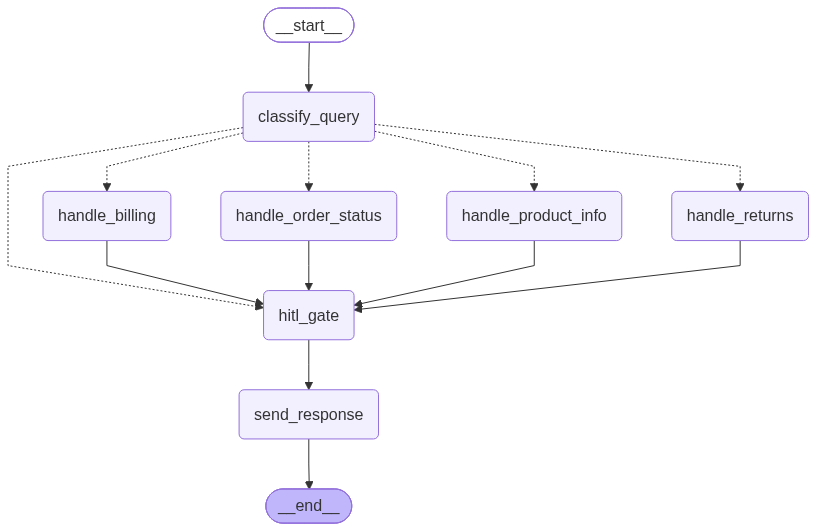

In [15]:
display(Image(compiled_agent.get_graph().draw_mermaid_png()))

## Test Case 1: Routine Query — Bronze Customer, Simple Order Status

This should flow straight through without triggering HITL:

`classify_query` → `handle_order_status` → `hitl_gate` (auto-approve) → `send_response` → END

In [16]:
# Test Case 1: Routine query - no HITL triggered
config_1 = {"configurable": {"thread_id": "ticket-routine-001"}}

result_1 = compiled_agent.invoke({
    "customer_query": "Where is my order ORD-1001? It was supposed to arrive yesterday.",
    "customer_id": "CUST-004",
    "customer_tier": "bronze",
    "order_value": 3500,
    "category": "",
    "priority": "",
    "response": "",
    "needs_human_review": False,
    "human_decision": {},
    "conversation_history": "",
}, config=config_1)

print(f"Category: {result_1['category']}")
print(f"Priority: {result_1['priority']}")
print(f"Needs Human Review: {result_1['needs_human_review']}")
print(f"\nFinal Response:\n{result_1['response']}")

Category: order_status
Priority: medium
Needs Human Review: False

Final Response:
Your order ORD-1001 for the Laptop has been shipped and is expected to arrive in 2 days. I understand it was supposed to arrive yesterday, so there might be a slight delay. If you need any further assistance, please let us know!


## Test Case 2: Platinum Customer Complaint — HITL Triggered

Mrs. Sunita Reddy (platinum tier, \u20b99.2L total spend) is unhappy about a damaged product. This triggers HITL because: **platinum tier + high priority**.

The graph will:
1. Classify the query
2. Generate an AI response via the returns handler
3. **PAUSE** at `hitl_gate` — sending the AI response + all context to a human reviewer
4. Wait for the human to approve, modify, or reject the response
5. Resume with the human's decision

In [17]:
# ---- Step 1: Invoke the graph - it will PAUSE at hitl_gate ----
config_2 = {"configurable": {"thread_id": "ticket-platinum-001"}}

result_2 = compiled_agent.invoke({
    "customer_query": "I received a damaged laptop worth 1,20,000 rupees. I want a full refund and compensation. This is unacceptable for a platinum customer!",
    "customer_id": "CUST-005",
    "customer_tier": "platinum",
    "order_value": 120000,
    "category": "",
    "priority": "",
    "response": "",
    "needs_human_review": False,
    "human_decision": {},
    "conversation_history": "",
}, config=config_2)

print("Graph paused for human review!")

# ---- Step 2: Inspect what the human reviewer sees ----
state_2 = compiled_agent.get_state(config_2)
print(f"\nGraph is paused at node(s): {[t.name for t in state_2.tasks]}")
print("\n--- REVIEW PAYLOAD SENT TO HUMAN ---")
for task in state_2.tasks:
    if task.interrupts:
        payload = task.interrupts[0].value
        print(json.dumps(payload, indent=2, ensure_ascii=False))

Graph paused for human review!

Graph is paused at node(s): ['hitl_gate']

--- REVIEW PAYLOAD SENT TO HUMAN ---
{
  "message": "Human review required for this ticket",
  "reason": "Platinum customer + High priority",
  "customer_id": "CUST-005",
  "customer_name": "Sunita Reddy",
  "customer_tier": "platinum",
  "total_spend": 920000,
  "past_tickets": 12,
  "category": "returns",
  "priority": "high",
  "order_value": 120000,
  "customer_query": "I received a damaged laptop worth 1,20,000 rupees. I want a full refund and compensation. This is unacceptable for a platinum customer!",
  "ai_draft_response": "Dear Valued Platinum Customer, we sincerely apologize for the inconvenience caused by receiving a damaged laptop. As per our policy, you are eligible for an instant replacement or a full refund. Please confirm if you prefer a refund, and we will arrange a return pickup within 24 hours and process your refund within 5-7 business days. While we cannot provide additional compensation, w

## How Does the Human Manager Actually Provide This Decision in Production?

In this lab, the manager's decision is a hardcoded Python dictionary — which is perfect for learning the `interrupt()`/`Command(resume=...)` pattern. But how does this actually work in a **deployed system**?

The key insight is that LangGraph's `interrupt()` simply **pauses the graph and saves its state to a checkpoint**. The graph doesn't care *how* the human decision arrives — it just waits for `Command(resume=decision)` to be called. This decouples the graph logic from the delivery mechanism.

Here are the most common production implementations:

### 1. LangGraph Platform + LangSmith Studio (Recommended for Getting Started)

LangGraph Platform provides a **built-in HITL web dashboard** out of the box:
- When `interrupt()` fires, the graph state is automatically persisted to a **PostgreSQL database** (not just in-memory)
- **LangSmith Studio** shows a web UI listing all pending interrupts with their payloads
- The human reviewer opens the dashboard, sees all the context (customer name, order value, AI recommendation), and clicks Approve / Modify / Reject
- The platform automatically calls `Command(resume=decision)` and the graph continues
- **No custom UI or API needed** — it's included in the platform

### 2. Custom Web Dashboard (FastAPI + React/Streamlit)

For organizations that need a branded internal tool, the typical architecture is:

```
Graph hits interrupt()
    → State saved to PostgreSQL/Redis
    → API sends notification (email / Slack / push notification) to the reviewer
    → Reviewer opens internal dashboard (React, Streamlit, or Retool)
    → Dashboard displays the interrupt payload (customer info, AI response, risk factors)
    → Reviewer clicks Approve / Modify / Reject, optionally adds notes
    → Frontend calls POST /api/tickets/{thread_id}/resume with the decision payload
    → Backend calls graph.invoke(Command(resume=decision), config={"configurable": {"thread_id": thread_id}})
    → Graph resumes from the exact checkpoint where it paused
```

The key implementation detail: your FastAPI endpoint stores the `thread_id` when the interrupt fires, and uses the **same `thread_id`** when resuming. This is how LangGraph knows which paused graph instance to wake up.

### 3. Messaging Integration (Slack / Microsoft Teams)

Many companies integrate HITL directly into their existing communication tools:
- When `interrupt()` fires, a **Slack message** is posted to a `#loan-approvals` channel with the interrupt payload formatted as a rich message
- The message includes **interactive buttons**: Approve, Modify, Reject
- When the manager clicks a button, a **Slack webhook** fires back to your server
- Your server calls `Command(resume={"action": "approve", ...})` to resume the graph
- For modifications, clicking "Modify" opens a **Slack modal** where the manager can edit the response text before submitting

This is popular because managers don't need to learn a new tool — they review and approve directly in Slack/Teams where they already work.

### 4. Enterprise Queue-Based Systems (Jira / ServiceNow / SQS)

For large enterprises with existing ticket management systems:
- `interrupt()` creates a **ticket** in ServiceNow or Jira via API
- The ticket contains the full interrupt payload as structured fields
- The review team processes tickets through their normal workflow
- When the ticket is resolved (approved/rejected), a **webhook or automation rule** triggers the resume
- This approach integrates HITL into existing compliance and audit workflows, which is critical in regulated industries (banking, healthcare, insurance)

### What Stays the Same Across All Approaches

Regardless of which delivery mechanism you choose, the **LangGraph code is identical**:

```python
# In the graph node — always the same
human_decision = interrupt(payload)  # Pauses here

# On the resume side — always the same  
graph.invoke(Command(resume=decision), config=thread_config)  # Resumes here
```

The `interrupt()` and `Command(resume=...)` pattern is **transport-agnostic**. You write the graph logic once, and swap the delivery mechanism (dashboard, Slack, Jira) without changing any graph code.

---

**In our lab below**, the `manager_decision` dictionary simulates what any of these systems would send back. The important thing you're learning is the **pattern** — the transport layer is a deployment concern covered in Lab 25.


In [18]:
# ---- Step 3: Human manager reviews and provides decision ----
manager_decision = {
    "action": "modify",
    "modified_response": (
        "Dear Mrs. Reddy, I sincerely apologize for this experience. "
        "As a valued platinum customer, we are processing an immediate full refund "
        "of \u20b91,20,000 AND a \u20b95,000 store credit as compensation for the inconvenience. "
        "Our quality team has been notified about this issue. "
        "I will personally follow up within 24 hours to ensure everything is resolved. "
        "\u2014 Support Manager"
    ),
    "notes": "Approved refund + added 5K compensation for platinum retention. Escalated to quality team."
}

# ---- Step 4: Resume the graph with the human decision ----
result_2_final = compiled_agent.invoke(Command(resume=manager_decision), config=config_2)

print("Graph resumed with human decision!")
print(f"\nNeeds Human Review: {result_2_final['needs_human_review']}")
print(f"Human Action: {result_2_final['human_decision'].get('action', 'N/A')}")
print(f"\nFinal Response:\n{result_2_final['response']}")

Graph resumed with human decision!

Needs Human Review: True
Human Action: modify

Final Response:
[Human-Reviewed] Dear Mrs. Reddy, I sincerely apologize for this experience. As a valued platinum customer, we are processing an immediate full refund of ₹1,20,000 AND a ₹5,000 store credit as compensation for the inconvenience. Our quality team has been notified about this issue. I will personally follow up within 24 hours to ensure everything is resolved. — Support Manager


## Test Case 3: High-Value Order Dispute — HITL Triggered

A bronze-tier customer disputes a \u20b975,000 order. Even though the customer is bronze, the high order value (> \u20b950,000) triggers HITL.

In [19]:
# Step 1: Invoke - will PAUSE at hitl_gate due to high order value
config_3 = {"configurable": {"thread_id": "ticket-highvalue-001"}}

result_3 = compiled_agent.invoke({
    "customer_query": "I never received my laptop order ORD-1001 worth 75,000 rupees but tracking shows delivered. I want a refund.",
    "customer_id": "CUST-001",
    "customer_tier": "bronze",
    "order_value": 75000,
    "category": "",
    "priority": "",
    "response": "",
    "needs_human_review": False,
    "human_decision": {},
    "conversation_history": "",
}, config=config_3)

print("Graph paused for human review (high-value order)!")

# Step 2: Check the interrupt
state_3 = compiled_agent.get_state(config_3)
for task in state_3.tasks:
    if task.interrupts:
        payload = task.interrupts[0].value
        print(f"Reason: {payload['reason']}")
        print(f"Order Value: \u20b9{payload['order_value']:,}")

# Step 3: Human approves the AI response as-is
approve_decision = {
    "action": "approve",
    "notes": "AI response is appropriate. Approved refund investigation."
}

# Step 4: Resume
result_3_final = compiled_agent.invoke(Command(resume=approve_decision), config=config_3)

print(f"\nHuman Action: {result_3_final['human_decision'].get('action')}")
print(f"\nFinal Response:\n{result_3_final['response']}")

Graph paused for human review (high-value order)!
Reason: High-value order (₹75,000)
Order Value: ₹75,000

Human Action: approve

Final Response:
[Human-Approved] Hello! I have checked your order ORD-1001 for the Laptop worth ₹75,000. According to our records, the status of your order is "shipped" and the estimated delivery time is 2 days. It has not been marked as delivered yet.

If you have not received the laptop yet, please allow a couple of days for the delivery to arrive. If you still do not receive it after that, please let us know, and we will assist you further with your refund request. 

Feel free to reach out if you need any more help!


## Memory: Multi-Turn Conversations

Because we compiled with `MemorySaver`, the agent remembers previous messages within the same thread. Let's have a 2-turn conversation using the same `thread_id`.

In [20]:
# Turn 1: Customer asks about an order
config_memory = {"configurable": {"thread_id": "ticket-memory-001"}}

turn_1 = compiled_agent.invoke({
    "customer_query": "What is the status of my order ORD-1003?",
    "customer_id": "CUST-003",
    "customer_tier": "silver",
    "order_value": 45000,
    "category": "",
    "priority": "",
    "response": "",
    "needs_human_review": False,
    "human_decision": {},
    "conversation_history": "",
}, config=config_memory)

print("--- Turn 1 ---")
print(f"Response: {turn_1['response'][:300]}")

# Check that state is saved in memory
saved_state = compiled_agent.get_state(config_memory)
print(f"\nState saved in memory: category={saved_state.values.get('category')}, priority={saved_state.values.get('priority')}")
print(f"Thread ID: {config_memory['configurable']['thread_id']}")

--- Turn 1 ---
Response: Your order ORD-1003 for the Smartphone is currently processing. It is expected to be delivered in 5 days. If you need any further assistance, feel free to ask!

State saved in memory: category=order_status, priority=low
Thread ID: ticket-memory-001


In [21]:
# Turn 2: Follow-up question on the SAME thread
# The agent can access previous state because MemorySaver stores it
turn_2 = compiled_agent.invoke({
    "customer_query": "Can I cancel that order and get a refund instead?",
    "customer_id": "CUST-003",
    "customer_tier": "silver",
    "order_value": 45000,
    "category": "",
    "priority": "",
    "response": "",
    "needs_human_review": False,
    "human_decision": {},
    "conversation_history": "",
}, config=config_memory)

print("--- Turn 2 (Follow-up) ---")
print(f"Category: {turn_2['category']}")
print(f"Response: {turn_2['response'][:300]}")

# Show that the state history is preserved
history = list(compiled_agent.get_state_history(config_memory))
print(f"\nTotal state snapshots in thread: {len(history)}")
print("MemorySaver keeps full conversation history for this thread!")

--- Turn 2 (Follow-up) ---
Category: returns
Response: Thank you for reaching out! If your order falls within the return window—7 days for electronics or 15 days for clothing and accessories—you can cancel it and receive a refund. Please let us know your order details, and we’ll arrange a return pickup within 24 hours. Once we receive the item, your ref

Total state snapshots in thread: 12
MemorySaver keeps full conversation history for this thread!


## Cross-Session Memory with InMemoryStore

`MemorySaver` only remembers within a thread (conversation). But what about remembering a customer across DIFFERENT conversations?

`InMemoryStore` provides a key-value store that persists across threads:
- Store customer history under a namespace: `("customers", customer_id)`
- Retrieve it in any new conversation
- Use it to personalize responses ("I see you contacted us last week about...")

This pattern is used in Lab 9 when we build the full multi-agent system. Here is the basic pattern.

In [22]:
# Create an InMemoryStore for cross-session customer data
store = InMemoryStore()

# Store a customer interaction record after resolving a ticket
store.put(
    namespace=("customers", "CUST-005"),
    key="ticket-platinum-001",
    value={
        "date": "2025-04-11",
        "category": "returns",
        "summary": "Damaged laptop - full refund + 5K compensation approved",
        "resolution": "Human-reviewed and modified response",
        "satisfaction": "pending"
    }
)

# Later, in a NEW conversation, retrieve this customer's history
customer_history = store.search(("customers", "CUST-005"))
print("Cross-session customer history for CUST-005:")
for item in customer_history:
    print(f"  Ticket: {item.key}")
    print(f"  Data: {json.dumps(item.value, indent=4)}")

print("\nThis history is available across ALL threads for this customer.")
print("In Lab 9, we integrate this into the graph nodes directly.")


Cross-session customer history for CUST-005:
  Ticket: ticket-platinum-001
  Data: {
    "date": "2025-04-11",
    "category": "returns",
    "summary": "Damaged laptop - full refund + 5K compensation approved",
    "resolution": "Human-reviewed and modified response",
    "satisfaction": "pending"
}

This history is available across ALL threads for this customer.
In Lab 9, we integrate this into the graph nodes directly.


## Conclusion: Spine A Progress

**Key Takeaways:**
1. `interrupt(payload)` pauses the graph and sends context to a human reviewer
2. `Command(resume=decision)` resumes the graph with the human's decision
3. HITL triggers should be based on clear business rules (tier, value, escalation)
4. `MemorySaver` enables multi-turn conversations within a thread
5. `InMemoryStore` enables cross-session memory (customer history across conversations)
6. The same ShopSmart system from Lab 5 now handles routine AND high-stakes queries